## Phase 2: formal precision@K / recall@K evaluation

Walks through `src/models/evaluate_precision_at_k.py` step by step, reusing
its actual functions (and the two baselines' fit/prepare/scale helpers)
rather than re-deriving the logic here.

Goal: turn the informal "top-1% lift" sanity check both baseline notebooks
used into the real evaluation this project has been building toward - a
fixed contact-budget metric (precision@K / recall@K), compared against
random targeting, **scored on test exactly once**
(`docs/decisions/004-three-way-split.md`). See `docs/concepts_log.md`'s
2026-09-18 entry for the full concept explanation.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(str(Path.cwd().parent))
sys.path.append(str(Path.cwd().parent / "src"))

from models.baseline_lightgbm import fit_baseline as fit_lightgbm
from models.baseline_logistic_regression import (
    fit_baseline as fit_logistic_regression,
    prepare_features,
    scale_continuous,
    top_k_lift,
)
from models.evaluate_precision_at_k import (
    K_FRACS,
    build_comparison_table,
    load_all_splits,
    print_comparison_table,
)

### Load all three splits

Unlike the two baseline notebooks (which only needed train + val), this one
needs test too - but only to score it, never to pick between models or tune
anything. That decision was already made informally in the two baseline
sessions (LightGBM's val numbers looked better) and is revisited below once
test's numbers come in.

In [2]:
df = load_all_splits()

by_split = df.groupby("split")["adoption"].agg(["size", "mean"])
by_split = by_split.rename(columns={"size": "rows", "mean": "adoption_rate"})
by_split

,rows,adoption_rate
split,,
test,2665623,0.004783
train,7694326,0.006329
val,1751740,0.00438


### Refit both baselines on train

Same feature set, same train-only scaling, same LightGBM early-stopping
setup as the two baseline sessions - nothing about the models changes here,
only the evaluation. Val is still used for LightGBM's early stopping (model
selection), never for the final reported numbers below.

In [3]:
train_df = df[df["split"] == "train"]
val_df = df[df["split"] == "val"]
test_df = df[df["split"] == "test"]

X_train, y_train = prepare_features(train_df)
X_val, y_val = prepare_features(val_df)
X_test, y_test = prepare_features(test_df)

X_train_scaled, X_val_scaled, scaler = scale_continuous(X_train, X_val)
X_test_scaled = X_test.copy()
X_test_scaled[scaler.feature_names_in_] = scaler.transform(X_test[scaler.feature_names_in_])

lr_model = fit_logistic_regression(X_train_scaled, y_train)
lgb_model = fit_lightgbm(X_train, y_train, X_val, y_val)

print("both baselines refit on train.")

both baselines refit on train.


### Score test - exactly once

This is the one time in the whole project either model touches the test
set. Everything below is computed from these two score arrays.

In [4]:
lr_test_scores = lr_model.predict_proba(X_test_scaled)[:, 1]
lgb_test_scores = lgb_model.predict_proba(X_test)[:, 1]

print(f"test set: n={len(y_test):,}, adoption_rate={y_test.mean():.3%}")

test set: n=2,665,623, adoption_rate=0.478%


### Precision@K, recall@K, lift@K vs. random targeting

Precision@K: of the top-K contacted customers by predicted score, what
fraction actually adopt. Recall@K: of every adopter in the whole test set,
what fraction fall inside that top-K list. Random targeting's expected
precision@K is just the base rate (any random sample estimates the
population rate); its expected recall@K is k_frac itself.

In [5]:
table = build_comparison_table(y_test, {"logistic_regression": lr_test_scores, "lightgbm": lgb_test_scores})
print_comparison_table(table)

              model k_frac  n_contacted  n_adopters_captured precision recall   lift
logistic_regression   0.1%         2665                  232    8.705%   1.8% 18.20x
           lightgbm   0.1%         2665                  228    8.555%   1.8% 17.89x
             random   0.1%         2665                   13    0.478%   0.1%  1.00x
logistic_regression   0.5%        13328                 1104    8.283%   8.7% 17.32x
           lightgbm   0.5%        13328                 1131    8.486%   8.9% 17.74x
             random   0.5%        13328                   64    0.478%   0.5%  1.00x
logistic_regression   1.0%        26656                 2149    8.062%  16.9% 16.86x
           lightgbm   1.0%        26656                 2153    8.077%  16.9% 16.89x
             random   1.0%        26656                  127    0.478%   1.0%  1.00x
logistic_regression   2.0%        53312                 3809    7.145%  29.9% 14.94x
           lightgbm   2.0%        53312                 3784    7

### Precision, recall, and lift curves across contact budgets

The same comparison table as a curve, so the precision/recall trade-off as
the contact budget grows is visible at a glance rather than read row by row
from the table above.

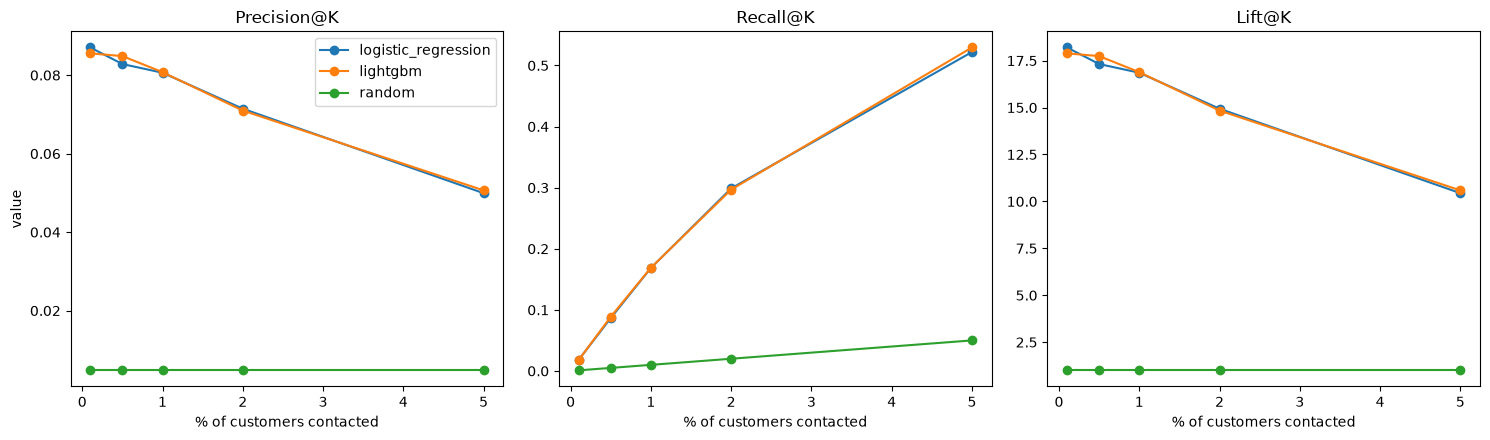

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics = ["precision", "recall", "lift"]
titles = ["Precision@K", "Recall@K", "Lift@K"]

for ax, metric, title in zip(axes, metrics, titles):
    for model_name in ["logistic_regression", "lightgbm", "random"]:
        subset = table[table["model"] == model_name].sort_values("k_frac")
        ax.plot([k * 100 for k in subset["k_frac"]], subset[metric], marker="o", label=model_name)
    ax.set_xlabel("% of customers contacted")
    ax.set_title(title)

axes[0].set_ylabel("value")
axes[0].legend()
plt.tight_layout()
plt.show()

### A real finding: the val-vs-test LightGBM edge shrinks to a tie

Both baseline sessions used val's top-1% lift as their headline comparison
number, and LightGBM looked clearly ahead there (17.13x vs. LR's 14-17x).
Scoring test - the number that actually counts - tells a different story:
the two models are essentially tied, and LR is even slightly ahead at a
couple of budgets. Val only has 7,673 adoption events vs. test's 12,749, so
part of that earlier gap looks like it was noise from the smaller val
sample rather than a robust LightGBM advantage.

In [7]:
lr_val_scores = lr_model.predict_proba(X_val_scaled)[:, 1]
lgb_val_scores = lgb_model.predict_proba(X_val)[:, 1]

comparison = pd.DataFrame({
    "val lift@1%": [top_k_lift(y_val, lr_val_scores), top_k_lift(y_val, lgb_val_scores)],
    "test lift@1%": [top_k_lift(y_test, lr_test_scores), top_k_lift(y_test, lgb_test_scores)],
}, index=["logistic_regression", "lightgbm"])
comparison

,val lift@1%,test lift@1%
logistic_regression,16.591021,16.856369
lightgbm,17.125375,16.879901


### Takeaways

- Built the fixed-contact-budget evaluation this project has been building
  toward since Phase 2 started: precision@K/recall@K/lift@K for both
  baselines vs. random targeting, scored on test exactly once.
- At a 1% contact budget (~26,656 test customers), both models land around
  8.0-8.1% precision and 16.9% recall, a ~16.9x lift over random targeting -
  contacting the top 1% by score would reach about 1 in 6 of all adopters
  in the whole test set while calling roughly 1 in 12 correct guesses,
  instead of roughly 1 in 200 by calling randomly.
- LR and LightGBM are **essentially tied on test**, unlike val where
  LightGBM looked clearly ahead - a reminder that a model-selection number
  from a smaller validation sample doesn't always survive contact with the
  real held-out set, and that the val-vs-test check above (not just the
  headline test table) is worth doing before trusting which model "won."
- As the contact budget grows, precision decays toward the base rate while
  recall grows - there's no single "right" K without a real contact-
  capacity/cost constraint, which is exactly what Phase 4's targeting
  strategy and simulated ROI work will supply.
- Next: `reports/02_baseline_model.md` write-up (closes out Phase 2), then
  Phase 3 - SHAP explainability and identifying an under-served,
  high-propensity segment.